# Pro player cohorts, part 6: what explains the difference in rejuvenation?

**Purpose**: `pro_player_roster_aging_curve.ipynb` found `delta`
(year-over-year median active-player age change, benchmarked against
+1.0/year = fully stagnant) rises with years-since-release -- rookie
dilution fades as a title matures. This notebook tests six candidate
explanations for *why* some titles/years rejuvenate more than others,
raised directly in discussion:

1. **Scene growth rate** -- is the title's active roster count itself
   growing, flat, or shrinking? A growing scene creates new roster
   slots that must be filled by someone, independent of attrition.
2. **Roster churn rate** -- already built in `pro_player_roster_churn.ipynb`;
   does more team-hopping correlate with more rejuvenation? (Weaker
   causal story -- a transfer between two veteran teams doesn't
   rejuvenate anything -- worth ruling in or out cheaply.)
3. **Grassroots tournament count** -- raw count of tier-3/4 events per
   title per year (`tournaments_lpdb_competitive`). More open-entry
   events = more chances for an unknown player to get discovered.
4. **Grassroots tournament share** -- tier-3/4 events as a fraction of
   *all* that title's tournaments that year -- distinct from the raw
   count above (a title can have many grassroots events just because it
   has many events overall; share asks whether the *mix* skews
   toward open entry, not just the volume).
5. **Audience growth** -- `monthly_category_history` (Kaggle import,
   2016-2024(ish), category-wide not esports-specific, confidence=
   `proxy_estimate` -- flagged, not treated as `verified`). Plausible
   mechanism: growing audience -> more sponsor/org investment -> more
   new team slots created.
6. **Franchised league structure** -- categorical. Only League of
   Legends (LCS, 2018) and VALORANT (VCT Partnership, 2023) have a real
   observable before/after transition in this project's tracked window;
   Overwatch League launched already franchised (no "before" to compare).

**The methodological point that has to be handled carefully**: `delta`
is already known to correlate with `years_since_release` (r=0.325,
established in the previous notebook). Several of these candidates
(scene growth, grassroots tournament count) plausibly correlate with
title age too -- younger titles are more likely to be growing and
adding events. A raw pooled correlation between a candidate and `delta`
could therefore just be re-finding the age effect already known about,
not a real independent driver. **Every candidate below is tested two
ways: a raw correlation, and a partial correlation controlling for
years_since_release** (via residualizing both variables against
years_since_release, then correlating the residuals) -- only the
partial correlation is evidence of something beyond "this title is
young/old."

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from etl.db import get_connection

COMMUNITY_TITLE_LISTS = {
    "C0": ["apex_legends", "fortnite", "league_of_legends", "overwatch", "rainbow_six_siege", "rocket_league", "teamfight_tactics", "valorant"],
    "C1": ["age_of_empires_ii", "counter_strike", "dota2", "hearthstone", "pubg", "starcraft2"],
    "C2": ["brawl_stars", "free_fire", "mobile_legends_bb", "pubg_mobile", "wild_rift"],
    "C3": ["guilty_gear", "mortal_kombat", "street_fighter", "tekken"],
}
community_by_title = {t: c for c, titles in COMMUNITY_TITLE_LISTS.items() for t in titles}
in_scope_titles = [t for t in community_by_title if community_by_title[t] != "C3"]

import yaml
with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]
display_name_by_id = {t["id"]: t["display_name"] for t in titles_config if t.get("is_active")}

ACTUAL_RELEASE_YEAR = {
    "age_of_empires_ii": 1999, "starcraft2": 2010, "counter_strike": 2012, "dota2": 2013,
    "hearthstone": 2014, "rocket_league": 2015, "rainbow_six_siege": 2015, "overwatch": 2016,
    "league_of_legends": 2009, "mobile_legends_bb": 2016, "pubg": 2017, "pubg_mobile": 2018,
    "free_fire": 2017, "fortnite": 2017, "brawl_stars": 2018, "apex_legends": 2019,
    "teamfight_tactics": 2019, "wild_rift": 2020, "valorant": 2020,
}

def partial_corr(x, y, z):
    """Pearson correlation between x and y, controlling for z, via the
    residual method: regress x on z and y on z (simple linear fit),
    correlate the residuals. Equivalent to a standard partial correlation."""
    x, y, z = np.asarray(x, dtype=float), np.asarray(y, dtype=float), np.asarray(z, dtype=float)
    x_resid = x - np.polyval(np.polyfit(z, x, 1), z)
    y_resid = y - np.polyval(np.polyfit(z, y, 1), z)
    return pearsonr(x_resid, y_resid)

## Build the base panel: delta, years_since_release, active roster size

Identical construction to `pro_player_roster_aging_curve.ipynb` -- not
re-derived differently here, so `delta` stays directly comparable.

In [2]:
conn = get_connection()
sp = pd.DataFrame(conn.execute(
    "SELECT title_id, player_link, player_id, join_date, leave_date FROM squadplayers_lpdb WHERE join_date IS NOT NULL"
).fetchall(), columns=["title_id", "player_link", "player_id", "join_date", "leave_date"])
players = pd.DataFrame(conn.execute(
    "SELECT title_id, liquipedia_page, birthdate FROM players_lpdb WHERE birthdate IS NOT NULL"
).fetchall(), columns=["title_id", "liquipedia_page", "birthdate"])
conn.close()

sp["join_date"] = pd.to_datetime(sp["join_date"], errors="coerce")
sp["leave_date"] = pd.to_datetime(sp["leave_date"], errors="coerce")
sp = sp[(sp["join_date"] >= "1998-01-01") & (sp["title_id"].isin(in_scope_titles))].reset_index(drop=True)
players["birthdate"] = pd.to_datetime(players["birthdate"], errors="coerce")

m = sp.merge(players.rename(columns={"liquipedia_page": "player_link"}), on=["title_id", "player_link"], how="left").reset_index(drop=True)
unmatched_mask = m["birthdate"].isna().reset_index(drop=True)
fb = m.loc[unmatched_mask, ["title_id", "player_id"]].merge(
    players.rename(columns={"liquipedia_page": "player_id", "birthdate": "bd2"}), on=["title_id", "player_id"], how="left")
m.loc[unmatched_mask, "birthdate"] = fb["bd2"].values
m_birth = m.dropna(subset=["birthdate"])

span = m_birth.groupby(["title_id", "player_link"]).agg(
    first_join=("join_date", "min"), last_leave=("leave_date", "max"),
    any_open=("leave_date", lambda s: s.isna().any()), birthdate=("birthdate", "first"),
).reset_index()
span["career_end"] = np.where(span["any_open"] | span["last_leave"].isna(), pd.Timestamp("2026-10-02"), span["last_leave"])
span["career_end"] = pd.to_datetime(span["career_end"])

YEARS_RANGE = range(2012, 2027)
active_rows = []
for _, r in span.iterrows():
    by = r["birthdate"].year
    for y in YEARS_RANGE:
        y_start, y_end = pd.Timestamp(f"{y}-01-01"), pd.Timestamp(f"{y}-12-31")
        if r["first_join"] <= y_end and r["career_end"] >= y_start:
            active_rows.append((r["title_id"], y, y - by))
active_age_df = pd.DataFrame(active_rows, columns=["title_id", "year", "age"])
active_age_df = active_age_df[(active_age_df["age"] >= 10) & (active_age_df["age"] <= 45)]

panel = active_age_df.groupby(["title_id", "year"]).agg(median_age=("age", "median"), n=("age", "size")).reset_index()
panel = panel[panel["n"] >= 20].sort_values(["title_id", "year"])
panel["prev_median"] = panel.groupby("title_id")["median_age"].shift(1)
panel["prev_year"] = panel.groupby("title_id")["year"].shift(1)
panel["prev_n"] = panel.groupby("title_id")["n"].shift(1)
panel["delta"] = panel["median_age"] - panel["prev_median"]
panel["pool_growth_pct"] = (panel["n"] / panel["prev_n"] - 1) * 100
panel = panel[panel["year"] == panel["prev_year"] + 1].copy()
panel["community"] = panel["title_id"].map(community_by_title)
panel["release_year"] = panel["title_id"].map(ACTUAL_RELEASE_YEAR)
panel["years_since_release"] = panel["year"] - panel["release_year"]
print(f"Base panel: {len(panel)} (title, year) rows, {panel['title_id'].nunique()} titles")

Base panel: 187 (title, year) rows, 19 titles


## Candidate 2: roster churn rate (reused from `pro_player_roster_churn.ipynb`)

In [3]:
sp_sorted = sp.sort_values(["title_id", "player_link", "join_date"])
sp_sorted["stint_rank"] = sp_sorted.groupby(["title_id", "player_link"]).cumcount()
sp_sorted["is_debut_stint"] = sp_sorted["stint_rank"] == 0
sp_sorted["join_year"] = sp_sorted["join_date"].dt.year
transfer_events = sp_sorted[~sp_sorted["is_debut_stint"]].groupby(["title_id", "join_year"]).size().rename("transfers")

active_counts_rows = []
for (title_id, player), g in sp.groupby(["title_id", "player_link"]):
    first_join = g["join_date"].min()
    last_known_end = g["leave_date"].max()
    career_end = last_known_end if pd.notna(last_known_end) and not g["leave_date"].isna().any() else pd.Timestamp("2026-10-02")
    for y in YEARS_RANGE:
        y_start, y_end = pd.Timestamp(f"{y}-01-01"), pd.Timestamp(f"{y}-12-31")
        if first_join <= y_end and career_end >= y_start:
            active_counts_rows.append((title_id, y))
active_counts = pd.Series(active_counts_rows, name="key").value_counts()
active_counts.index = pd.MultiIndex.from_tuples(active_counts.index, names=["title_id", "join_year"])
active_counts = active_counts.rename("active_players")

churn = pd.concat([transfer_events, active_counts], axis=1).fillna(0)
churn["active_players"] = churn["active_players"].replace(0, np.nan)
churn["churn_rate"] = churn["transfers"] / churn["active_players"]
churn = churn.reset_index().rename(columns={"join_year": "year"})

panel = panel.merge(churn[["title_id", "year", "churn_rate"]], on=["title_id", "year"], how="left")
print(f"churn_rate matched for {panel['churn_rate'].notna().sum()} of {len(panel)} panel rows")

churn_rate matched for 187 of 187 panel rows


## Candidates 3 & 4: grassroots tournament count and share

In [4]:
conn = get_connection()
tourn = pd.DataFrame(conn.execute(
    "SELECT title_id, tier, start_date FROM tournaments_lpdb_competitive WHERE start_date IS NOT NULL AND title_id IN ({})".format(
        ",".join("?" * len(in_scope_titles))
    ), in_scope_titles
).fetchall(), columns=["title_id", "tier", "start_date"])
conn.close()
tourn["start_date"] = pd.to_datetime(tourn["start_date"], errors="coerce")
tourn = tourn.dropna(subset=["start_date"])
tourn["year"] = tourn["start_date"].dt.year
tourn["is_grassroots"] = tourn["tier"].isin(["3", "4"])

tourn_by_year = tourn.groupby(["title_id", "year"]).agg(
    total_tournaments=("tier", "size"), grassroots_count=("is_grassroots", "sum"),
).reset_index()
tourn_by_year["grassroots_share"] = tourn_by_year["grassroots_count"] / tourn_by_year["total_tournaments"] * 100

panel = panel.merge(tourn_by_year[["title_id", "year", "grassroots_count", "grassroots_share"]], on=["title_id", "year"], how="left")
print(f"grassroots figures matched for {panel['grassroots_count'].notna().sum()} of {len(panel)} panel rows")

grassroots figures matched for 187 of 187 panel rows


## Candidate 5: audience growth (Kaggle `monthly_category_history`, 2016+, `proxy_estimate` confidence)

In [5]:
conn = get_connection()
mch = pd.DataFrame(conn.execute(
    "SELECT title_id, year_month, hours_watched FROM monthly_category_history WHERE title_id IN ({})".format(
        ",".join("?" * len(in_scope_titles))
    ), in_scope_titles
).fetchall(), columns=["title_id", "year_month", "hours_watched"])
conn.close()
mch["year"] = mch["year_month"].str[:4].astype(int)
audience_by_year = mch.groupby(["title_id", "year"])["hours_watched"].sum().reset_index()
audience_by_year = audience_by_year.sort_values(["title_id", "year"])
audience_by_year["prev_hours"] = audience_by_year.groupby("title_id")["hours_watched"].shift(1)
audience_by_year["audience_growth_pct"] = (audience_by_year["hours_watched"] / audience_by_year["prev_hours"] - 1) * 100

panel = panel.merge(audience_by_year[["title_id", "year", "audience_growth_pct"]], on=["title_id", "year"], how="left")
print(f"audience_growth_pct matched for {panel['audience_growth_pct'].notna().sum()} of {len(panel)} panel rows (Kaggle coverage starts 2016)")

audience_growth_pct matched for 141 of 187 panel rows (Kaggle coverage starts 2016)


## Candidate 6: franchised league structure (categorical, only 2 real transitions in this window)

In [6]:
def franchised_flag(row):
    if row["title_id"] == "league_of_legends":
        return int(row["year"] >= 2018)
    if row["title_id"] == "valorant":
        return int(row["year"] >= 2023)
    return np.nan  # no observable transition for this title in the tracked window -- not scored either way

panel["franchised"] = panel.apply(franchised_flag, axis=1)
panel[["title_id", "year", "franchised"]][panel["franchised"].notna()].to_string()

'              title_id  year  franchised\n83   league_of_legends  2013         0.0\n84   league_of_legends  2014         0.0\n85   league_of_legends  2015         0.0\n86   league_of_legends  2016         0.0\n87   league_of_legends  2017         0.0\n88   league_of_legends  2018         1.0\n89   league_of_legends  2019         1.0\n90   league_of_legends  2020         1.0\n91   league_of_legends  2021         1.0\n92   league_of_legends  2022         1.0\n93   league_of_legends  2023         1.0\n94   league_of_legends  2024         1.0\n95   league_of_legends  2025         1.0\n96   league_of_legends  2026         1.0\n175           valorant  2021         0.0\n176           valorant  2022         0.0\n177           valorant  2023         1.0\n178           valorant  2024         1.0\n179           valorant  2025         1.0\n180           valorant  2026         1.0'

## The battery: raw correlation vs. partial correlation (controlling for years_since_release), for every candidate

In [7]:
candidates = ["pool_growth_pct", "churn_rate", "grassroots_count", "grassroots_share", "audience_growth_pct"]
battery_rows = []
for cand in candidates:
    sub = panel.dropna(subset=[cand, "delta", "years_since_release"])
    if len(sub) < 10:
        battery_rows.append({"candidate": cand, "n": len(sub), "raw_r": None, "raw_p": None, "partial_r": None, "partial_p": None})
        continue
    raw_r, raw_p = pearsonr(sub[cand], sub["delta"])
    part_r, part_p = partial_corr(sub[cand], sub["delta"], sub["years_since_release"])
    battery_rows.append({"candidate": cand, "n": len(sub), "raw_r": round(raw_r, 3), "raw_p": round(raw_p, 4), "partial_r": round(part_r, 3), "partial_p": round(part_p, 4)})

# Candidate 6 (franchised) handled separately -- categorical within-title before/after, not a pooled correlation.
for t in ["league_of_legends", "valorant"]:
    sub = panel[(panel["title_id"] == t) & panel["franchised"].notna()]
    before = sub[sub["franchised"] == 0]["delta"]
    after = sub[sub["franchised"] == 1]["delta"]
    print(f"{display_name_by_id[t]}: delta before franchising (n={len(before)}) mean={before.mean():.3f} | after (n={len(after)}) mean={after.mean():.3f}")

battery_df = pd.DataFrame(battery_rows).sort_values("partial_r", key=lambda s: s.abs(), ascending=False)
battery_df

League of Legends: delta before franchising (n=5) mean=0.200 | after (n=9) mean=0.556
VALORANT: delta before franchising (n=2) mean=0.000 | after (n=4) mean=0.500


,candidate,n,raw_r,raw_p,partial_r,partial_p
1,churn_rate,187,-0.203,0.0053,-0.122,0.0972
4,audience_growth_pct,141,-0.115,0.1745,-0.080,0.3428
3,grassroots_share,187,-0.059,0.4239,-0.049,0.5038
2,grassroots_count,187,-0.022,0.7633,-0.046,0.5296
0,pool_growth_pct,187,-0.065,0.3737,0.022,0.7693


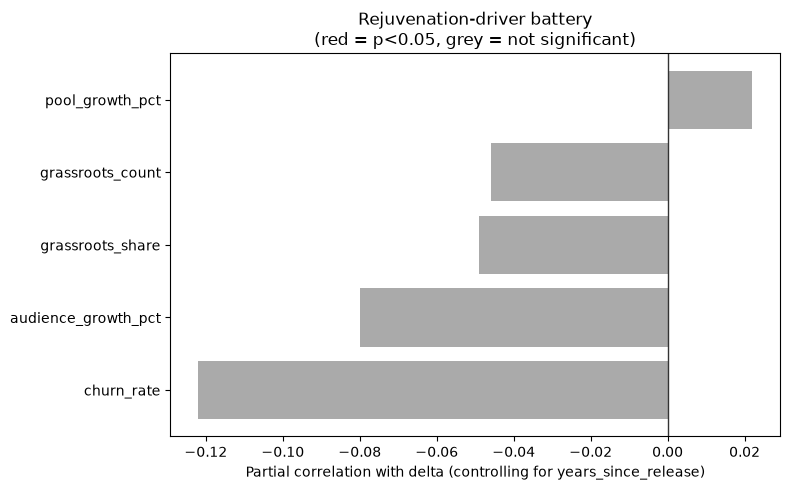

In [8]:
plot_df = battery_df.dropna(subset=["partial_r"])
fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ["#C44E52" if p is not None and p < 0.05 else "#AAAAAA" for p in plot_df["partial_p"]]
ax.barh(plot_df["candidate"], plot_df["partial_r"], color=bar_colors)
ax.axvline(0, color="#333", linewidth=1)
ax.set_xlabel("Partial correlation with delta (controlling for years_since_release)")
ax.set_title("Rejuvenation-driver battery\n(red = p<0.05, grey = not significant)")
plt.tight_layout()
plt.savefig(Path.cwd() / "_rejuvenation_drivers_fig1_battery.png", dpi=150, bbox_inches="tight")
plt.show()

### Read -- the battery mostly comes back empty, and that's a real finding, not a failed check

**None of the five continuous candidates show a significant partial
correlation with delta once years_since_release is controlled for.**
`churn_rate` comes closest (partial r=-0.122, p=0.097 -- marginal, not
significant) after looking strong raw (r=-0.203, p=0.0053) -- **most of
churn's apparent relationship with rejuvenation turns out to be the age
effect already known about**, not an independent driver: older titles
tend to have both lower churn and higher delta, and once that shared
cause is removed, churn's own leftover contribution is weak. Audience
growth (partial r=-0.080, p=0.343), grassroots tournament share
(r=-0.049, p=0.504), and scene growth rate (r=0.022, p=0.769) are all
indistinguishable from zero. **The user's own hypothesis -- more
grassroots tournament opportunity drives more rejuvenation -- is not
supported**: grassroots_count's partial correlation (r=-0.046, p=0.530)
is the second-weakest result in the whole battery, essentially no
signal in either direction.

**Franchising is the one candidate that shows a real, suggestive
direction -- but on far too small a sample to call it a finding.** Both
observable transitions point the same way: League of Legends' mean
delta rose from 0.20 (pre-2018) to 0.56 (post-2018); VALORANT's rose
from 0.00 (2021-2022) to 0.50 (2023+). Both say franchising is
associated with *less* rejuvenation, not more -- consistent with the
direction (if not quite the same specific metric) found in
`pro_player_roster_churn.ipynb`'s own franchising test, which found
LCS churn rising after 2018 rather than falling. But n=2 titles with
5-9 and 2-4 observations each is nowhere near enough to treat this as
confirmed -- it's the most mechanistically plausible story in this
battery (locking players into multi-year franchise deals is a direct,
literal way to suppress rookie turnover) and the one worth revisiting
if a third franchising transition becomes trackable.

**Net: this battery rules out several plausible mechanisms rather than
confirming one.** Scene growth, audience growth, and grassroots
tournament opportunity (both count and share) all fail to explain any
meaningful share of rejuvenation beyond simple title age. Churn rate's
relationship is mostly age in disguise. The real driver of why
rejuvenation fades as titles mature remains open -- something not
captured by this battery (genuine title-by-title idiosyncrasy, the kind
already seen in the Fortnite-vs-PUBG divergence in the generational-
cohort section, is still the leading candidate) or a structural effect
like franchising that this data can't yet test at adequate scale.

## Caveats

- **C3 excluded entirely**, same as every notebook in this thread.
- **`monthly_category_history` is category-wide, not esports-specific**
  (`confidence='proxy_estimate'`, per `etl/schema.sql`'s own comment) --
  includes ranked play, guides, and cosmetics content alongside
  competitive viewing. A real signal here is about the title's whole
  audience, not specifically its esports audience.
- **Candidate 6 (franchising) has only 2 titles with an observable
  transition in this project's tracked window** -- too few to treat as
  a general test, shown descriptively rather than folded into the
  pooled battery.
- **Partial correlation controls for `years_since_release` linearly** --
  if the true relationship between age and delta is curved (the
  previous notebook's binned means suggest it might be), a linear
  control could leave some age-related variance in the residuals,
  which would bias a candidate's partial correlation if that candidate
  is also nonlinearly related to age. Not corrected for here -- a
  polynomial or rank-based control would be the next refinement if any
  single candidate's result needs to be leaned on hard.
- **n per candidate varies** -- audience growth and grassroots figures
  both depend on upstream data (Kaggle coverage starting 2016;
  tournament records needing a real `start_date`), so each candidate's
  test runs on a different, generally smaller, subset of the full panel
  than the base `years_since_release` relationship did. Reported `n`
  per row, not assumed uniform.